# CNN Training

Target of this code is to train a CNN network to extract the needle position of an analog needle device.

### Preparing the training
* First all libraries are loaded
    * It is assumed, that they are installed during the Python setup
* matplotlib is set to print the output inline in the jupyter notebook

### Basic Parameter

In [1]:
# Model naming
TFlite_MainType: str = 'ana-class100'
TFlite_Version: str  = 'undefined'
TFlite_Size: str     = 's1'

# Validation size
# Note: 0.0 = 0% validation size, use all images for training
Validation_Percentage = 0.2

# Folders
Input_Dir: str  = 'data_resize_all'
Output_Dir: str = 'models/ana-class100'

In [2]:
# Parameters
TFlite_Version = "7-conv64"
Output_Dir = "models_tmp"


In [3]:
import os
import sys
import glob
from pathlib import Path
import random
import math
import numpy as np
from numpy import pi
import pandas as pd

from PIL import Image

import tensorflow as tf

from tensorflow import keras
#from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras.preprocessing.image import ImageDataGenerator

#import tensorflow.keras.backend as K
#from tensorflow.keras.callbacks import History 

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4)
np.set_printoptions(suppress=True)


# Make sure version is 4 characters long if version is defined as int (e.g. papermill paramter 100 -> 0100)
if isinstance(TFlite_Version, int):
    TFlite_Version = str(TFlite_Version).zfill(4)


# Prepare folders
if not (Path(Input_Dir).exists() and Path(Input_Dir).is_dir()): # Check if input is availabe
    sys.exit(f"Aborting: Folder '{Input_Dir}' does not exist.")
    
Path(Output_Dir).mkdir(parents=True, exist_ok=True)  # Create output folder if it doesn't exist


# Disable GPUs
try:
    tf.config.set_visible_devices([], 'GPU')
    visible_devices = tf.config.get_visible_devices()
    for device in visible_devices:
        assert device.device_type != 'GPU'
except:
    # Invalid device or cannot modify virtual devices once initialized.
    pass

2025-05-04 12:38:40.196047: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-04 12:38:40.199079: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-04 12:38:40.205583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746362320.219254    1995 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746362320.223382    1995 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 12:38:40.238989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

2025-05-04 12:38:42.735242: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Load training data
* The data is expected in the "Input_dir"
* Picture size must be 32x32 with 3 color channels (RGB)
* The filename contains the informations needed for training in the first 3 digits::
* Typical filename: 
    * x.y-zzzz.jpg 
    * e.g. "4.6_Lfd-1406_zeiger3_2019-06-02T050011"

|Place holder | Meaning                     | Usage        |
|------------- |-----------------------------|--------------|
| **x.y**          | readout value               | **to be learned** |
| zzzz        | additional information              | not needed   |

* The images are stored in the x_data[]
* The expected output for each image in the corresponding y_data[]
    * The periodic nature is reflected in a **sin/cos coding**, which allows to restore the angle/counter value with an arctan later on.

* The last step is a shuffle (from sklearn.utils) as the filenames are on order due to the encoding of the expected analog readout in the filename 

In [4]:
files = glob.glob(f"{Input_Dir}/*.jpg")
num_files = len(files)

f_data = np.empty(num_files, dtype="<U250")
x_data = np.empty((num_files, 32, 32, 3))
y_data = np.empty(num_files)

for i, aktfile in enumerate(files):
    base = os.path.basename(aktfile)

    # get label from filename (1.2_ new or 1_ old),
    if (base[1]=="."):
        target = base[0:3]
    else:
        target = base[0:1]
    category = float(target)
    
    test_image = Image.open(aktfile)
    test_image = np.array(test_image, dtype="float32")
    f_data[i] = aktfile
    x_data[i] = test_image
    y_data[i] = category

print("Data count: ", len(y_data))  
print(x_data.shape)

x_data, y_data, f_data = shuffle(x_data, y_data, f_data)
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=Validation_Percentage)
y_train = keras.utils.to_categorical(y_train*10, 100)
y_test = keras.utils.to_categorical(y_test*10, 100)

print(np.expand_dims(y_data, axis=1).shape)


Data count:  1739
(1739, 32, 32, 3)
(1739, 1)


### Distribution of the data

Uneven distribution of data can lead to poorer results.

In some classes (8.4) we have only 20 images. In other classes over 100 images.

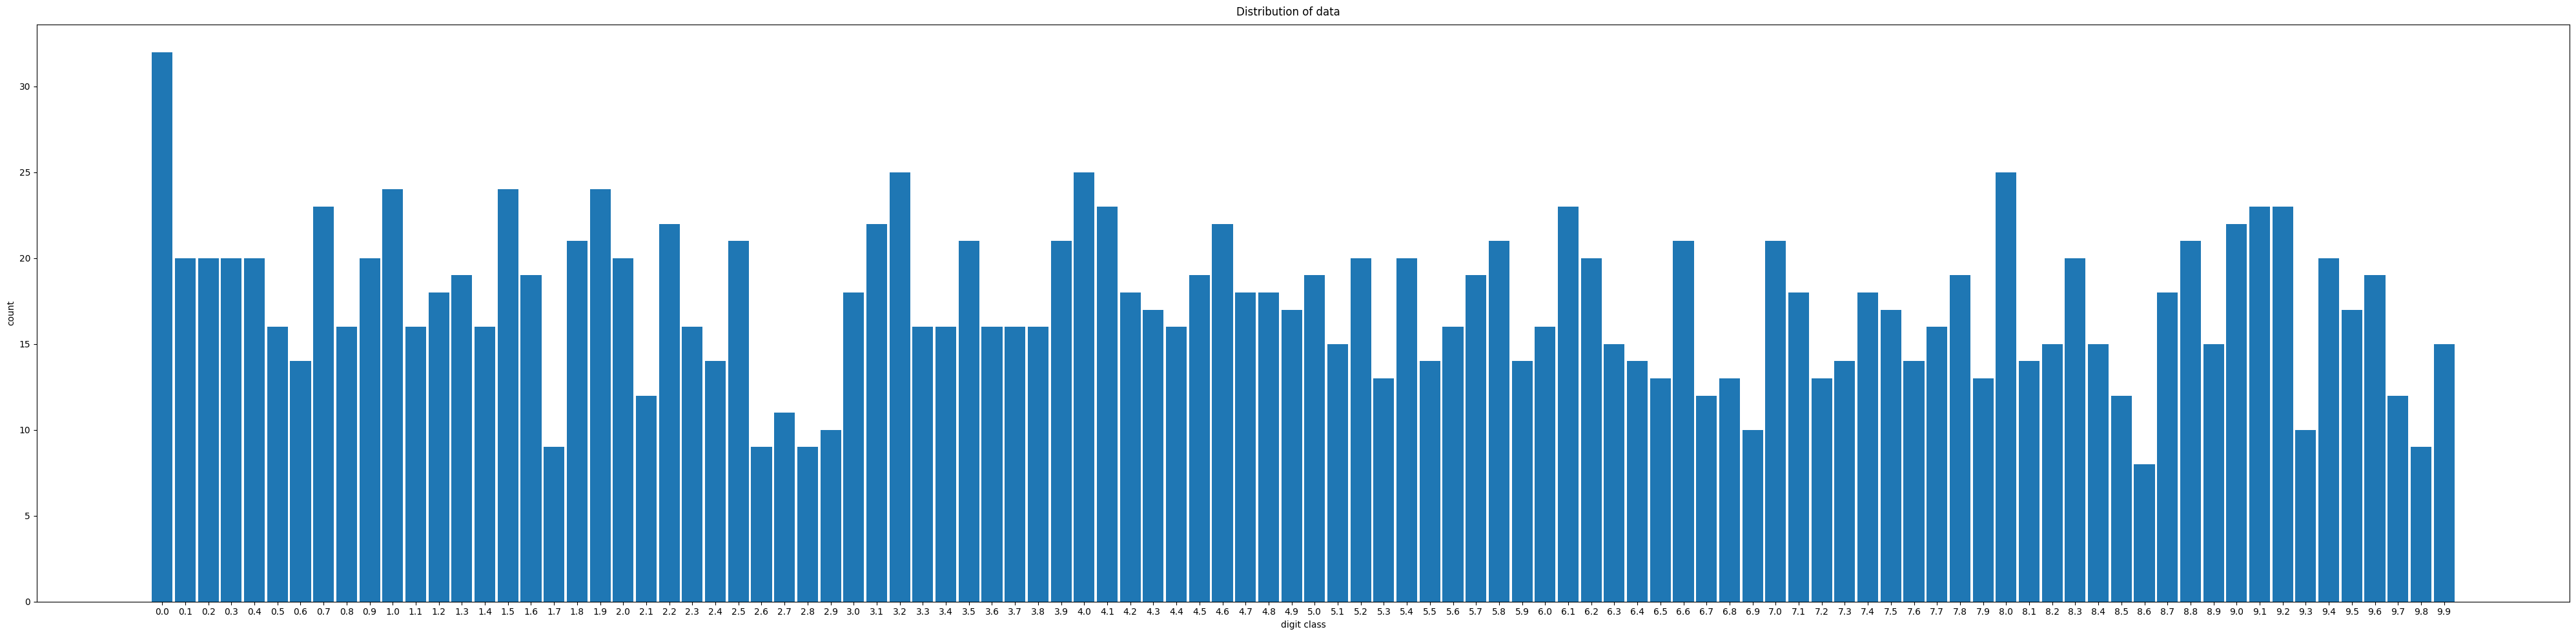

In [5]:
_, inverse = np.unique(y_data, return_inverse=True)
ziffer_bincount = np.bincount(inverse)
fig = plt.figure(figsize=(40, 10))
fig.suptitle("Distribution of data")
plt.bar(np.arange (0, 100/10, 0.1), ziffer_bincount, width=0.09, align='center')
plt.ylabel('count')
plt.xlabel('digit class')
plt.tight_layout()
_ = plt.xticks(np.arange(0, 100/10, 0.1))


### Define the model

The layout of the network ist a typcial CNN network with alternating 2x **Conv2D**, **BatchNormalization** and **MaxPool2D** layers. Finished after **flattening** with additional **Dense** layer.

**Dropout** between CNN layers are 0.2, between fully connected layers 0.4, but only the fully connected output layer.

* Shape of the input layer: (32, 32, 3)
* Shape of the output layer: (100) - classification 0.0 ... 9.9

In [6]:

"""inputs = Input(shape=(32, 32, 3))

x = BatchNormalization()(inputs)
x = Conv2D(64, (5, 5), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Conv2D(64, (1, 1), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)

x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)

x = BatchNormalization()(x)
x = Dropout(0.25)(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)

x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)

x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)

x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)

x = Flatten()(x)
x = Dropout(0.5)(x)

# Output layer for 100-class classification
output = Dense(100)(x)

model = tf.keras.Model(inputs=inputs, outputs=output)

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

model.summary()"""


inputs = Input(shape=(32, 32, 3))

x = Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(inputs)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

x = Flatten()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.4)(x)

# Output layer for 100-class classification
output = Dense(100)(x)

model = tf.keras.Model(inputs=inputs, outputs=output)

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,132 (656.77 KB)

 Trainable params: 167,908 (655.89 KB)

 Non-trainable params: 224 (896.00 B)

# Training
The input pictures are randomly scattered for brightness and pixel shift variations. These is implemented with a ImageDataGenerator.


The training is in one step. 

The best model will be stored as \<modelname\>_best.h5

### Augmentation

Augmentation uses shift, zoom, brightness, shear

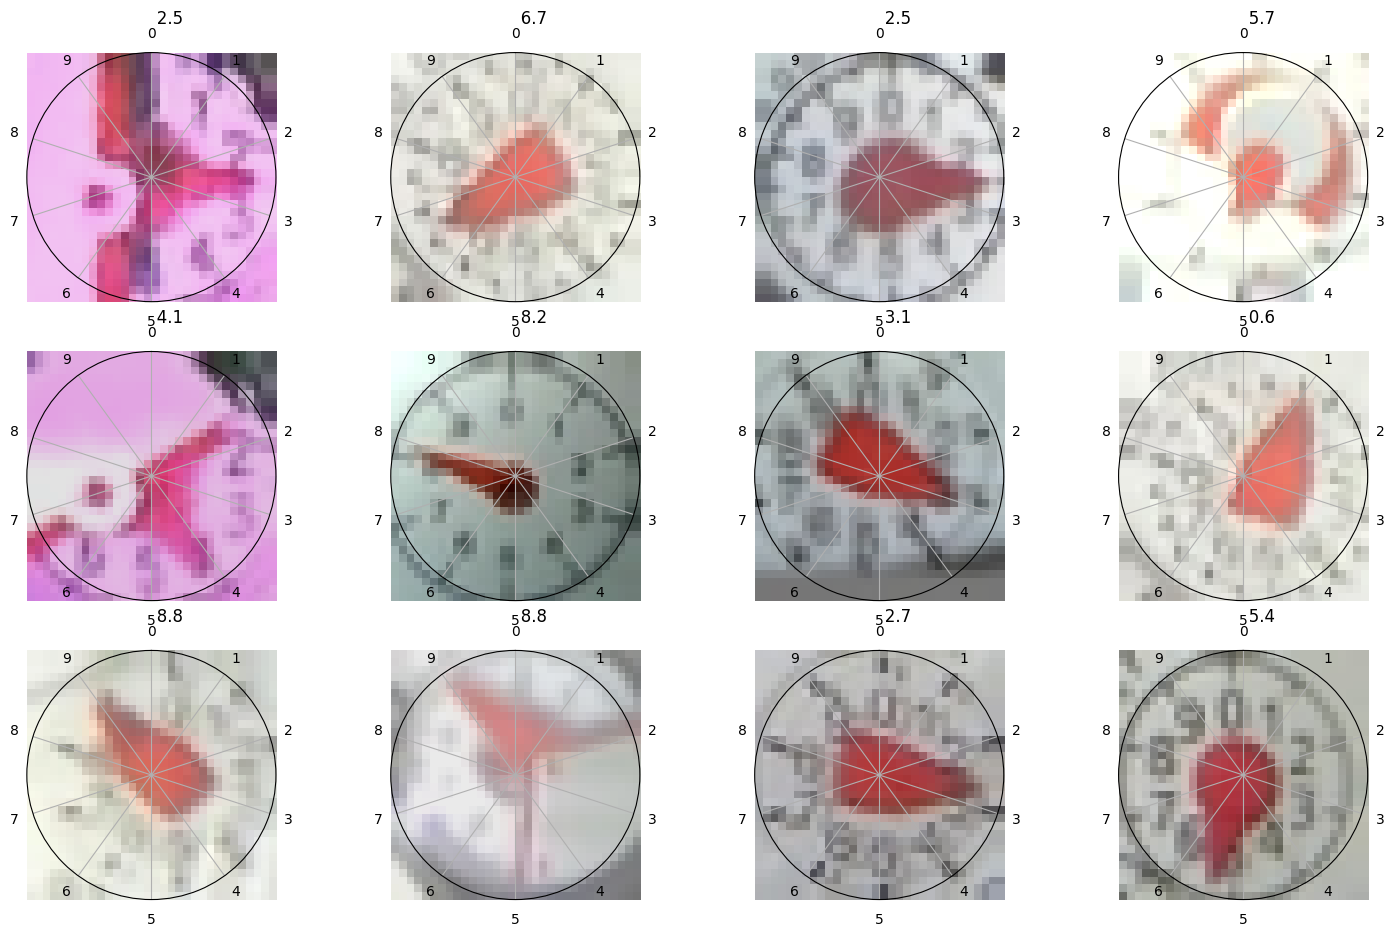

In [7]:
Batch_Size = 8
Shift_Range = 1
Zoom_Range = 0.05
Brightness_Range = 0.2
ShearRange= 1
Rotation_Range=0

def add_noise(img):
    '''Add random noise to an image'''
    VARIABILITY = 3
    deviation = VARIABILITY*random.random()
    noise = np.random.normal(0, deviation, img.shape)
    img += noise
    np.clip(img, 0., 255.)
    return img

datagen = ImageDataGenerator(width_shift_range=[-Shift_Range,Shift_Range], 
                height_shift_range=[-Shift_Range,Shift_Range],
                brightness_range=[1-Brightness_Range,1+Brightness_Range],
                zoom_range=Zoom_Range,
                channel_shift_range=5,
                shear_range=ShearRange,
                rotation_range=Rotation_Range,
                #preprocessing_function=add_noise
                #rescale=1/255
                )
datagen_val = ImageDataGenerator()
train_iterator = datagen.flow(X_train, y_train, batch_size=Batch_Size)
validation_iterator = datagen_val.flow(X_test, y_test, batch_size=Batch_Size)


columns=4
rows=3

fig = plt.figure(figsize=(18, 11))
for i in range(1, columns*rows +1):
    img, label = next(train_iterator)
    ax0 = fig.add_subplot(rows, columns, i)
    target = (np.argmax(label[0])/10)
    plt.title("{:10.1f}\n".format(target))  # set title
    plt.imshow(img[0].astype(np.uint8))
    plt.axis('off')
    ax=plt.gca()
    ax.get_xaxis().set_visible(False) 
    ax2 = fig.add_subplot(rows, columns, i, polar=True, label="polar")
    ax2.set_facecolor("None")
    # suppress the radial labels
    plt.setp(ax.get_yticklabels(), visible=False)

    # set the circumference labels
    ax2.set_xticks(np.linspace(0, 2*pi, 10, endpoint=False))
    ax2.set_xticklabels(range(10))
    ax2.yaxis.grid(False)
    
    # make the labels go clockwise
    ax2.set_theta_direction(-1)
    # place 0 at the top
    ax2.set_theta_offset(pi/2.0)    
    ax2.set_yticklabels([])


    # plt.grid('off')

    # put the points on the circumference
    plt.ylim(0,1)
plt.show()


In [8]:
Epoch_Anz = 400

earlystop = EarlyStopping(
    monitor='val_loss', 
    mode='min' , 
    patience=30, 
    verbose=0,  
    restore_best_weights=True
)

#mc = ModelCheckpoint(
    # TFliteNamingAndVersion + '_best.h5', 
    # monitor='val_loss', 
    # mode='min', 
    # verbose=0, 
    # save_best_only=True, 
    # initial_value_threshold=.9
#)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.9, 
    patience=5, 
    min_lr=1e-5, 
    verbose=0
)

history = model.fit(
    train_iterator, 
    validation_data=validation_iterator, 
    batch_size=Batch_Size, 
    epochs = Epoch_Anz,
    callbacks=[earlystop, reduce_lr],
    verbose=0
)


/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


### Result
 
* Visualization of the training and validation results
* Validation should not much over train validation, because of the augmentation of train data (validation data not)
* Beware, the best model will be used. This can be from an earlier epoch as the last. (mostly the last -30)


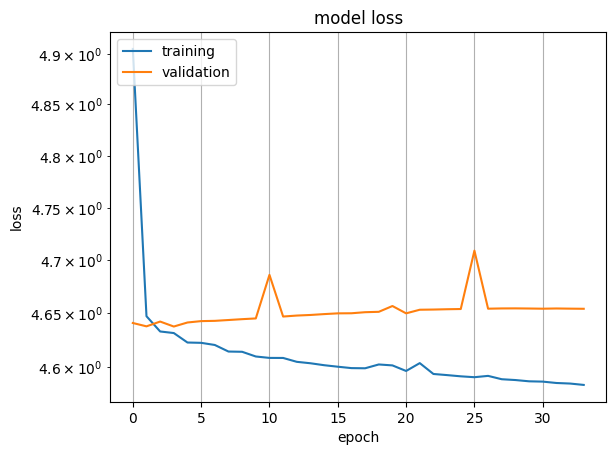

In [9]:
plt.semilogy(history.history['loss'])

if (Validation_Percentage > 0):
    plt.semilogy(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training','validation'], loc='upper left')
plt.grid(True)
plt.show()

### Model verification

* The following code uses the trained model to check the deviation for each picture (train + validation).
* The max_delta can be used to get the accuracy with allowed differences (for instance +/- 0.1)
* The first (max) 49 false predicted images will be shown
* A csv-file with all false predicted images will be created. It can be used for relabeling. Usage `python3 -m collectmeteranalog  --labelfile=ana-class100_s1_false_predicted.csv --model=ana-class100_s1q.tflite` (see https://github.com/haverland/collectmeteranalog)


 1/55 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step

14/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

27/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

40/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


Tested images: 1739. 1664 false predicted. Accuracy is: 0.043128234617596295


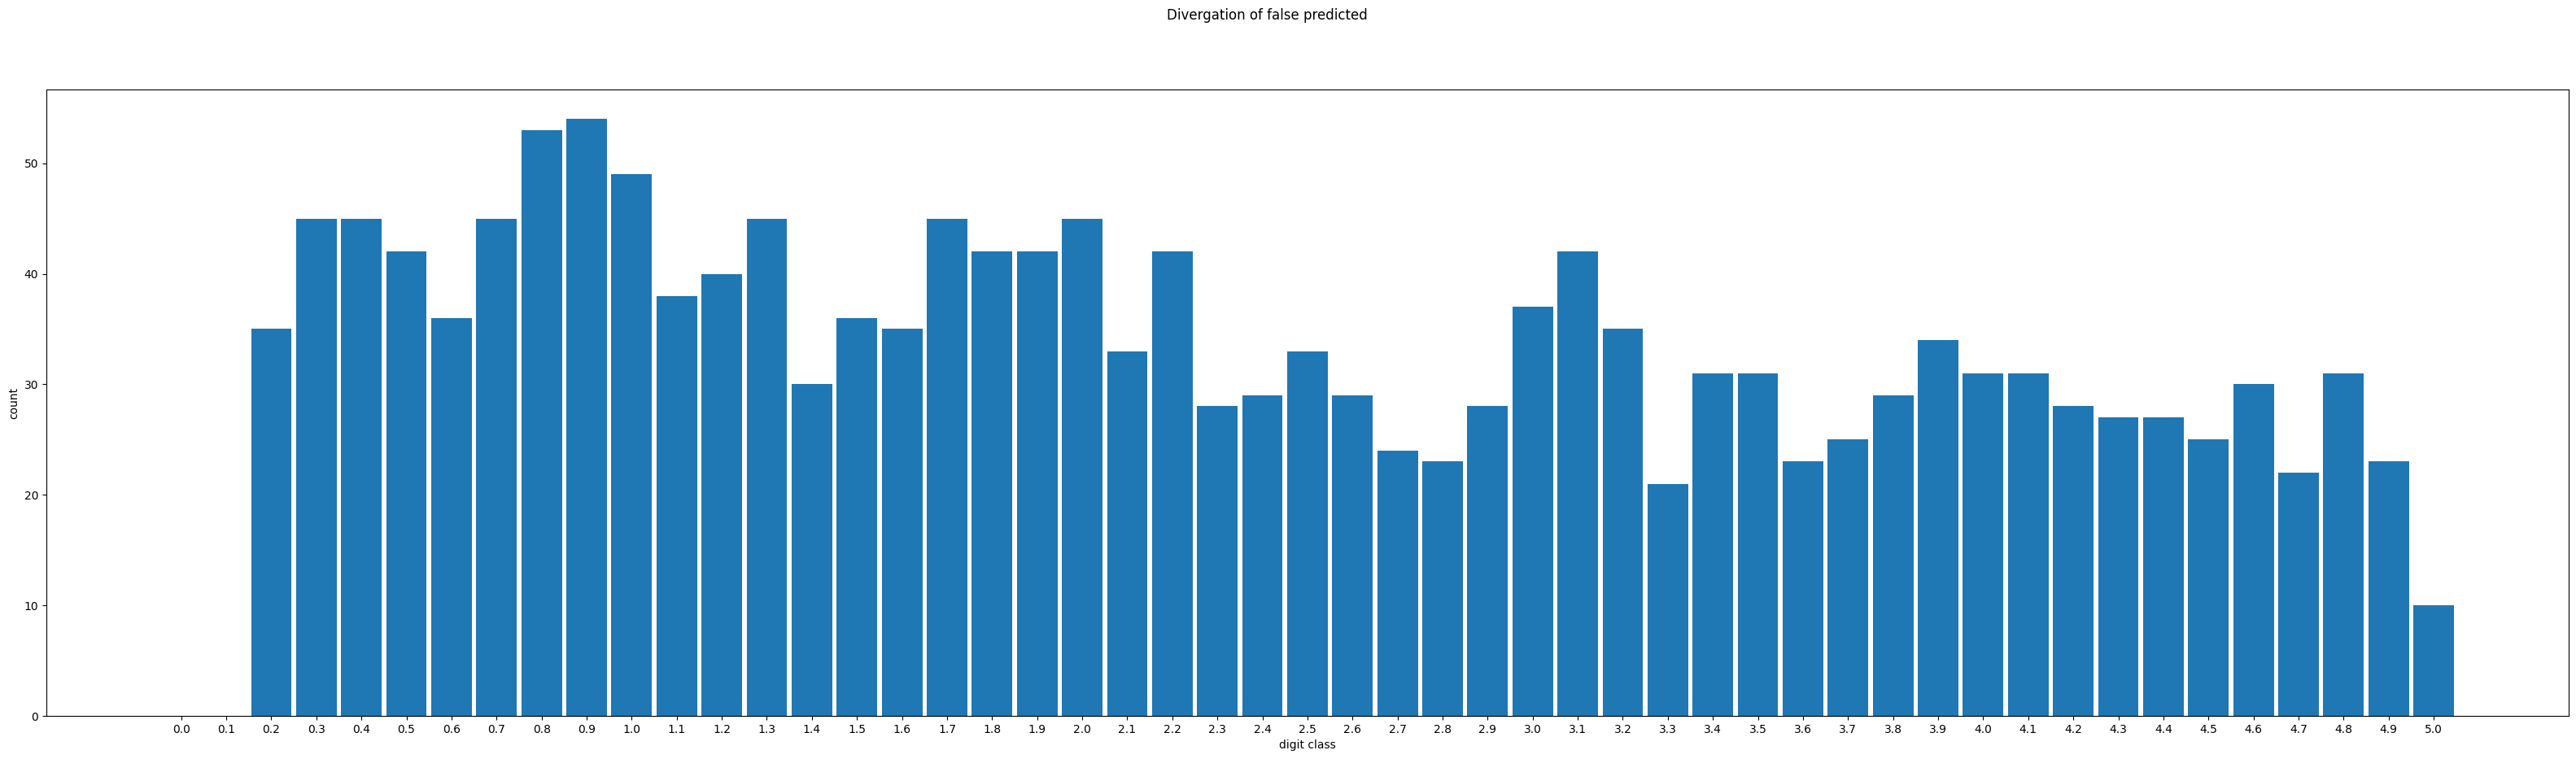

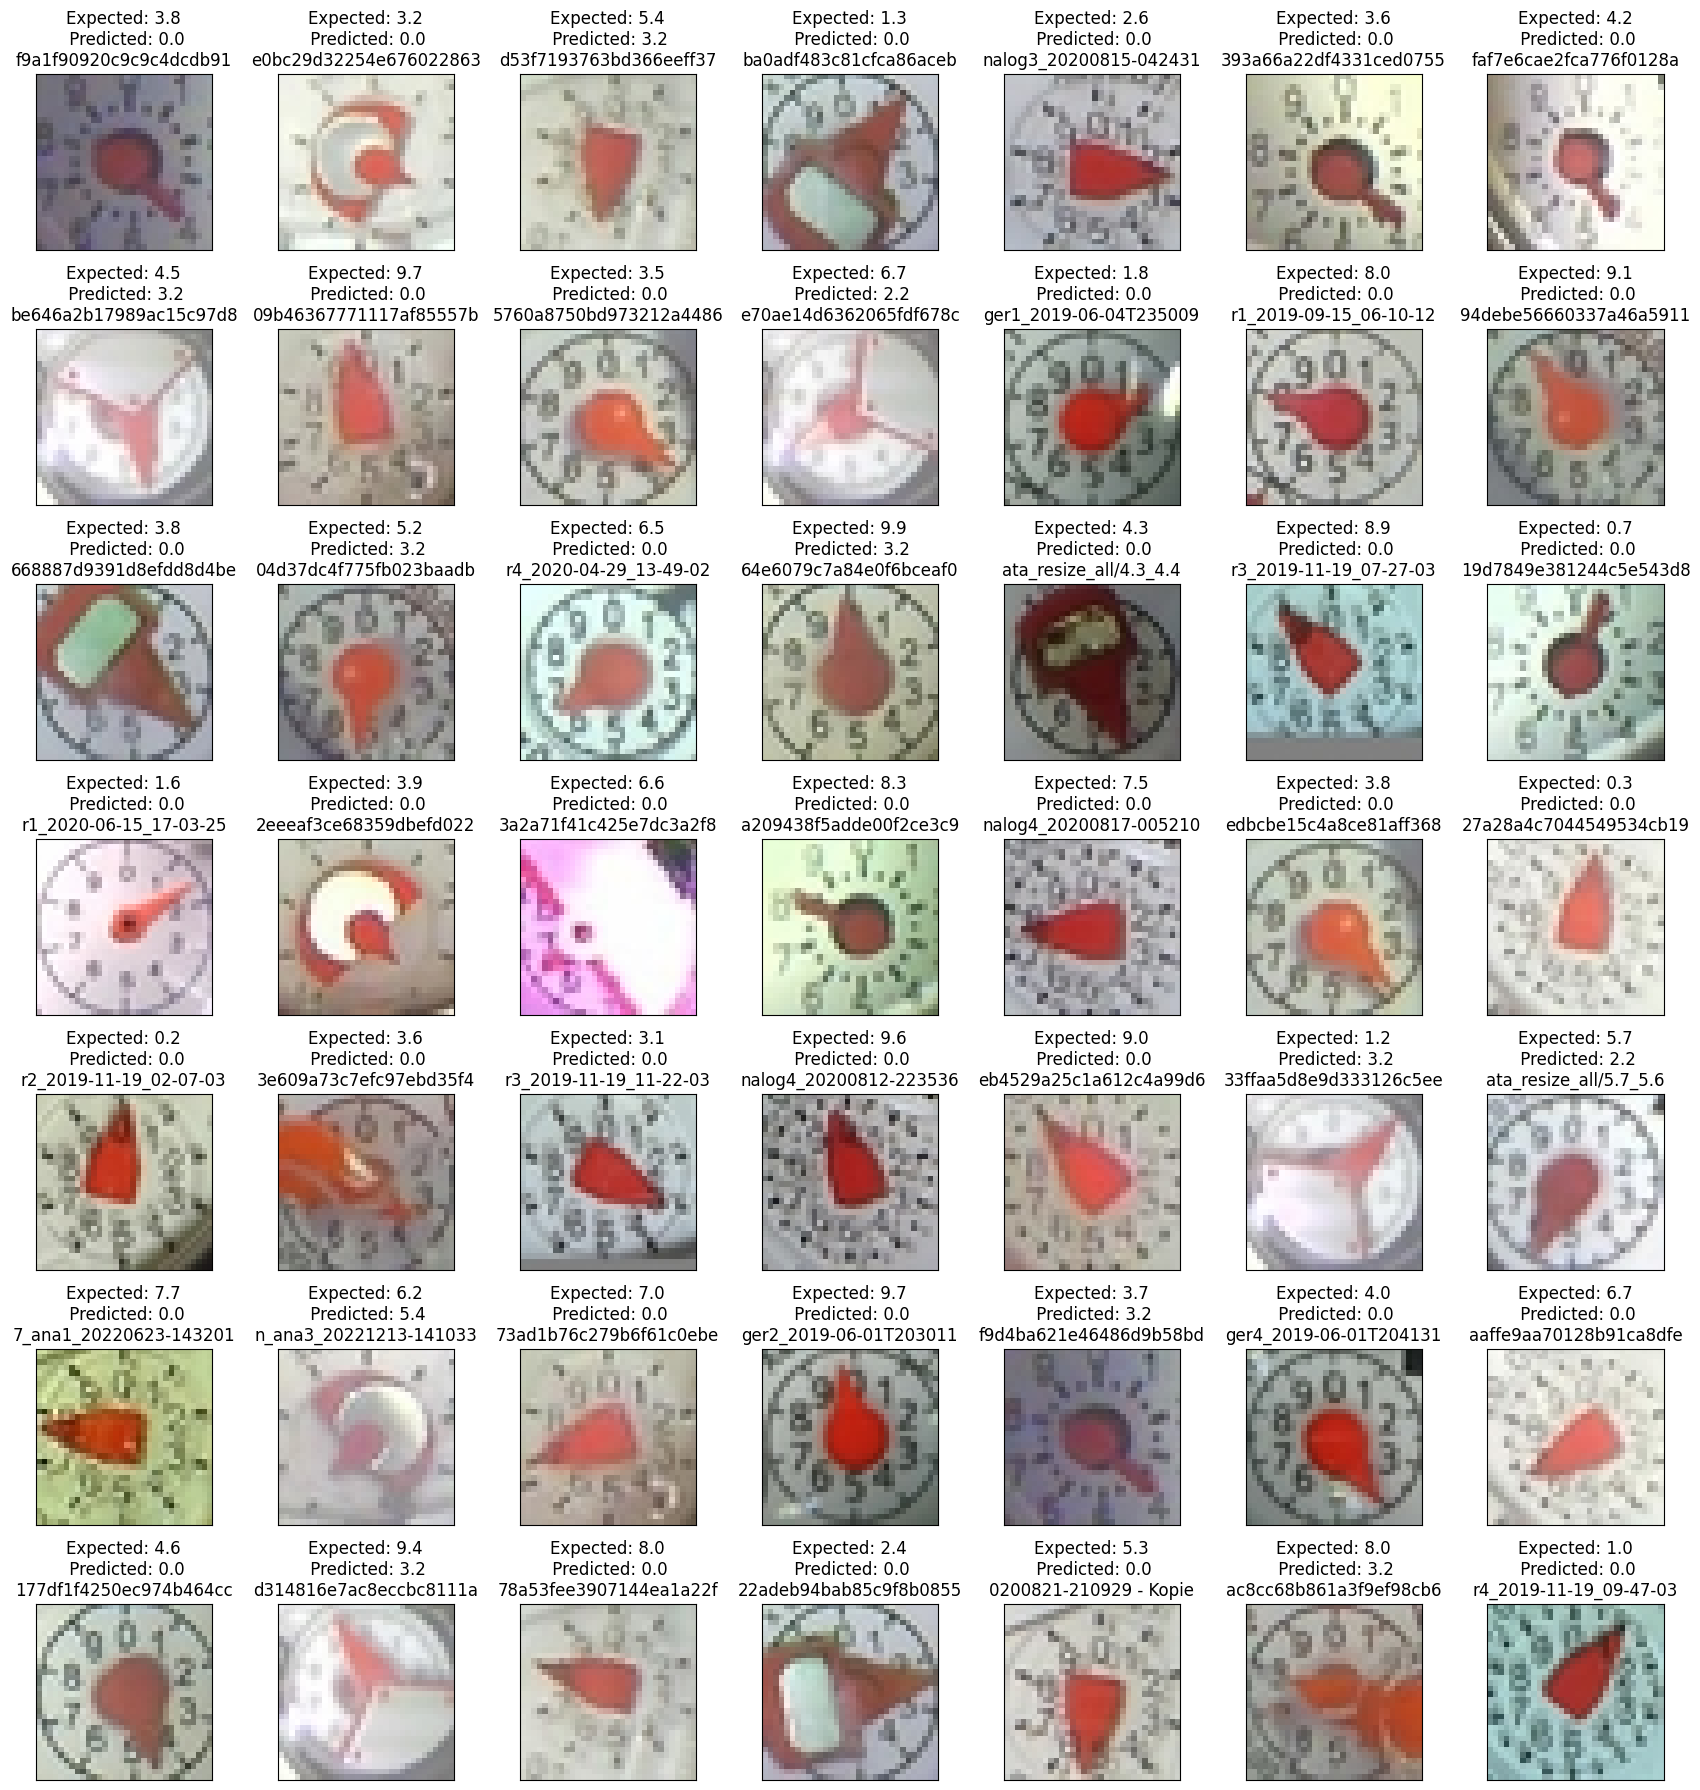

In [10]:
max_delta=0.11

def plot_dataset(images, labels, columns=10, rows=5, figsize=(18, 10)):

    fig = plt.figure(figsize=figsize)
    
    for i in range(1, columns*rows +1):
        if (i>len(labels)):
            break
        fig.add_subplot(rows, columns, i)
        plt.title(labels[i-1])  # set title
        plt.imshow((images[i-1]).astype(np.uint8), aspect='1', extent=[0, 1, 0, 1])
        # yellow lines
        ax=plt.gca()
        ax.get_yaxis().set_visible(False) 
        ax.get_xaxis().set_visible(False) 
        
        plt.tight_layout()
    plt.show()

def plot_divergence(divergationset, title1, nb_classes):
    fig = plt.figure(figsize=(40, 10))
    fig.suptitle(title1)
    plt.bar(np.arange (0, nb_classes/10, 0.1), divergationset, width=0.09, align='center')
    plt.ylabel('count')
    plt.xlabel('digit class')
    plt.xticks(np.arange(0, nb_classes/10, 0.1))
    return fig

#model = keras.models.load_model(TFliteNamingAndVersion + "_best.h5")

classes = model.predict(x_data.astype(np.float32))
predictions = np.argmax(classes, axis=1).reshape(-1)/10

# 9.9 <> 0 = 0.1 and 1.1 <> 1.2 = 0.1
differences = np.minimum(np.abs(predictions-y_data), np.abs(predictions-(10-y_data)))
# used for filtering
false_differences = differences>max_delta
# only differences bigger than delta. so small differences can be ignored in early stages
false_predicted = differences[false_differences]
false_images = x_data[false_differences]
false_labels = [ "Expected: " + str(y1) + "\n Predicted: " + str(p) + "\n" + str(f)[-26:-4] for y1, p, f in zip(y_data[false_differences], predictions[false_differences], f_data[false_differences])]
false_files = [ f for f in  f_data[false_differences]]

print(f"Tested images: {len(y_data)}. {len(false_predicted)} false predicted. Accuracy is: {1-len(false_predicted)/len(y_data)}")
# plot the differences (max difference can only be 5.0)
plot_divergence(np.bincount(np.array(np.round(false_predicted*10)).astype(int), minlength=51), "Divergation of false predicted", 51)

# plot the false predicted images
plot_dataset(np.array(false_images), false_labels, columns=7, rows=7, figsize=(18,18))
#print(false_files)
fpf = pd.DataFrame(false_files)

# the csv can be used with collectmeterdigits to fix labels
# python3 -m collectmeteranalog  --labelfile=ana-class10_0168_s1_false_predicted.csv --model=ana-class100_0168_s1_q.tflite
fpf.to_csv(f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}" + '_false_predicted.csv')


### Save the model

* Save the model to the file with the "tflite" file format
* quantize the model and store it as -q.tflite

In [11]:
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}.tflite"

# TensorFlow Lite conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open(FileName, "wb") as f:
    f.write(tflite_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpswaqbn2o/assets


INFO:tensorflow:Assets written to: /tmp/tmpswaqbn2o/assets


Saved artifact at '/tmp/tmpswaqbn2o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  140345381298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381299664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381301776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381300432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381302736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381301008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381302544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14034538130139

Model saved successfully. File: models_tmp/ana-class100_7-conv64_s1.tflite
File size: 677364 bytes


W0000 00:00:1746362384.316877    1995 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746362384.316903    1995 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 12:39:44.317154: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpswaqbn2o
2025-05-04 12:39:44.317939: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 12:39:44.317951: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpswaqbn2o
I0000 00:00:1746362384.328380    1995 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-05-04 12:39:44.330078: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 12:39:44.382397: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpswaqbn2o
2025-05-04 12:39:44.397090: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

In [12]:
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}_q.tflite"

# Representative dataset function
def representative_dataset():
    for n in range(x_data[0].shape[0]):
        data = np.expand_dims(x_data[n], axis=0)
        yield [data.astype(np.float32)]

# TensorFlow Lite conversion with optimizations
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
tflite_quant_model = converter.convert()

# Save the converted model to the specified file
with open(FileName, "wb") as f:
    f.write(tflite_quant_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpwv4647kt/assets


INFO:tensorflow:Assets written to: /tmp/tmpwv4647kt/assets


Saved artifact at '/tmp/tmpwv4647kt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  140345381298896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381299856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381300816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381298512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381299664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381301776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381300432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381302736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381301008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345381302544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14034538130139

/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model saved successfully. File: models_tmp/ana-class100_7-conv64_s1_q.tflite
File size: 178560 bytes


W0000 00:00:1746362385.026163    1995 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746362385.026180    1995 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 12:39:45.026321: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwv4647kt
2025-05-04 12:39:45.027228: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 12:39:45.027239: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpwv4647kt
2025-05-04 12:39:45.037187: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 12:39:45.088803: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpwv4647kt
2025-05-04 12:39:45.103468: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 77149 microseconds.
fully_quantize: 0, inference_type: 6, input_i